In [1]:
import pandas  as pd 
import matplotlib.pyplot as plt
import seaborn as Sns
df =pd.read_csv('superstore.csv.csv',encoding='latin1')
print("dataset loaded!")
print("shape:",df.shape)
print(df.columns.tolist)

dataset loaded!
shape: (2121, 21)
<bound method IndexOpsMixin.tolist of Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')>


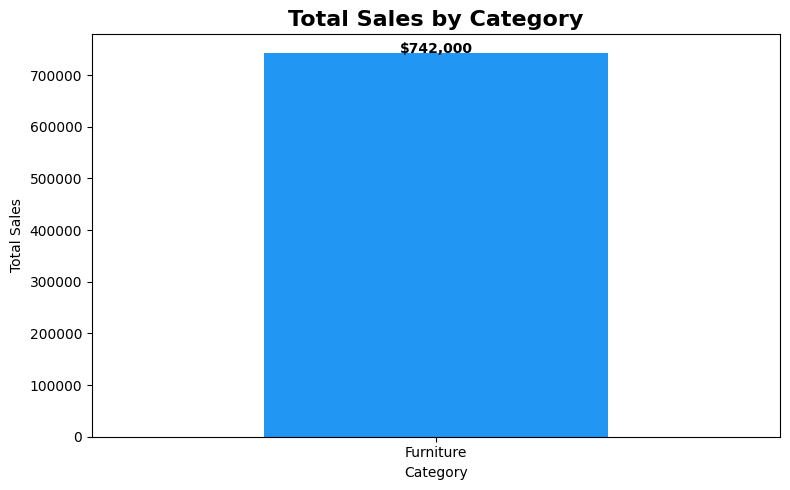

 Chart 1 Done!


In [2]:
# Chart 1: Sales by Category (Bar Chart)
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors = ['#2196F3', '#FF9800', '#4CAF50']
category_sales.plot(kind='bar', color=colors)
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
for i, v in enumerate(category_sales):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png')
plt.show()
print(" Chart 1 Done!")



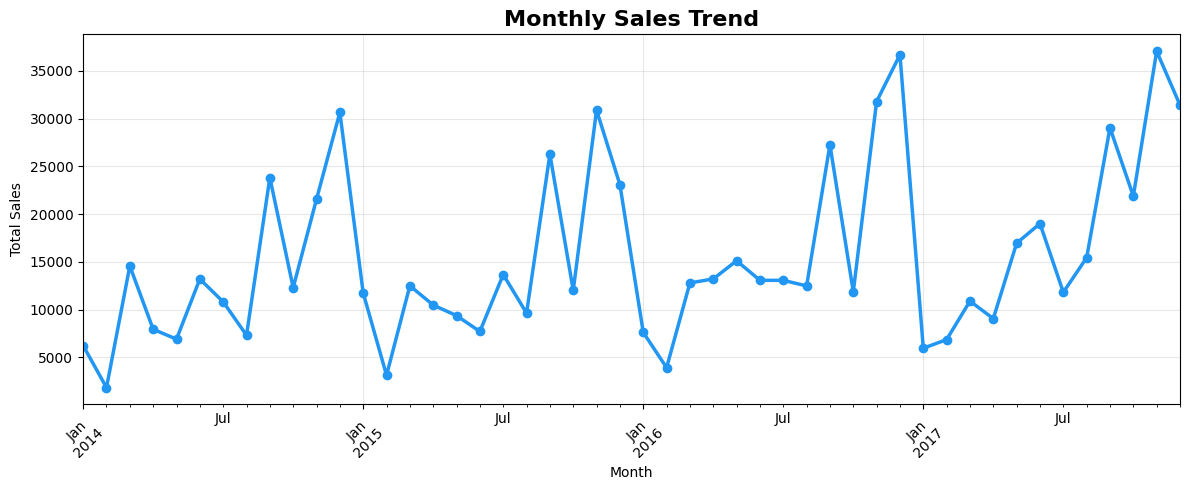

Chart 2 Done!


In [3]:
# Chart 2: Monthly Sales Trend (Line Chart)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', color='#2196F3', linewidth=2.5, marker='o')
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png')
plt.show()
print("Chart 2 Done!")

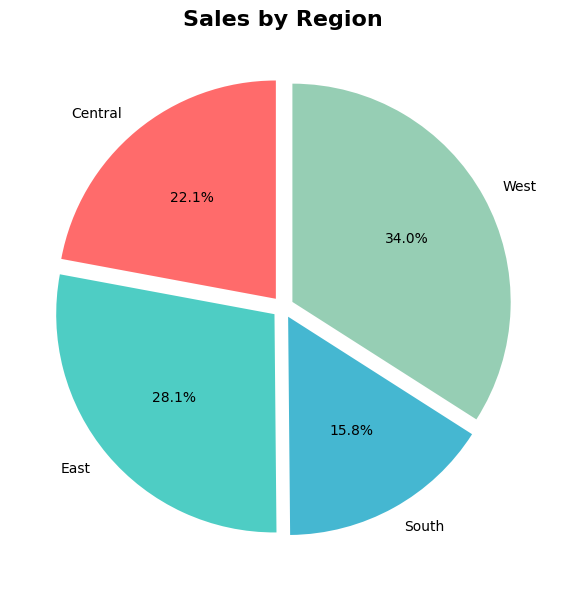

Chart 3 Done!


In [4]:
#Chart 3: Sales by Region (Pie Chart)
plt.figure(figsize=(8,6))
region_sales = df.groupby('Region')['Sales'].sum()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.pie(region_sales, 
        labels=region_sales.index, 
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05]*4)
plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_sales_by_region.png')
plt.show()
print("Chart 3 Done!")

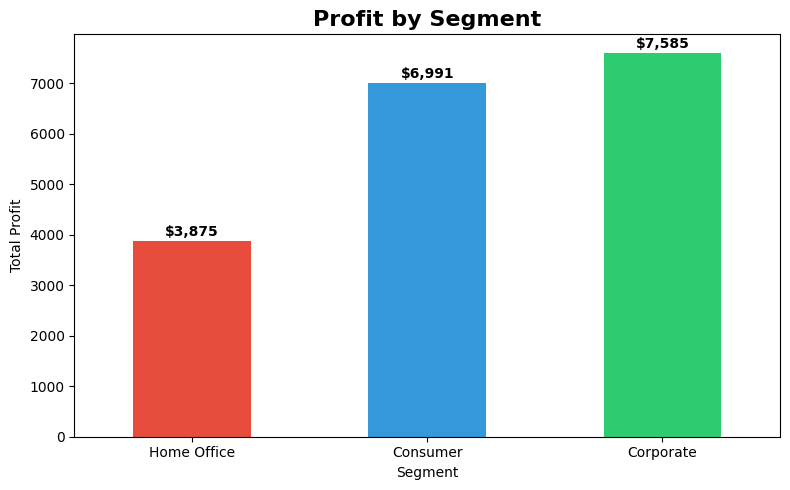

 Chart 4 Done!


In [5]:


# Chart 4: Profit by Segment (Bar Chart)
plt.figure(figsize=(8,5))
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values()
colors = ['#E74C3C', '#3498DB', '#2ECC71']
segment_profit.plot(kind='bar', color=colors)
plt.title('Profit by Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
for i, v in enumerate(segment_profit):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_profit_by_segment.png')
plt.show()
print(" Chart 4 Done!")


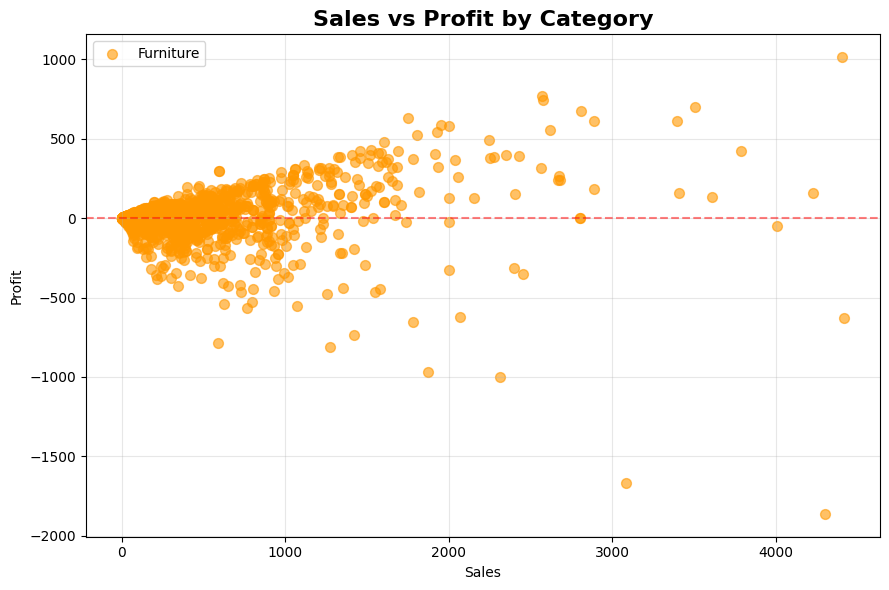

 Chart 5 Done!


In [6]:


# Chart 5: Sales vs Profit (Scatter Plot)
plt.figure(figsize=(9,6))
colors_map = {'Technology':'#2196F3', 
              'Furniture':'#FF9800', 
              'Office Supplies':'#4CAF50'}

for category, group in df.groupby('Category'):
    plt.scatter(group['Sales'], 
                group['Profit'],
                label=category,
                color=colors_map[category],
                alpha=0.6,
                s=50)

plt.title('Sales vs Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend()
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_sales_vs_profit.png')
plt.show()
print(" Chart 5 Done!")

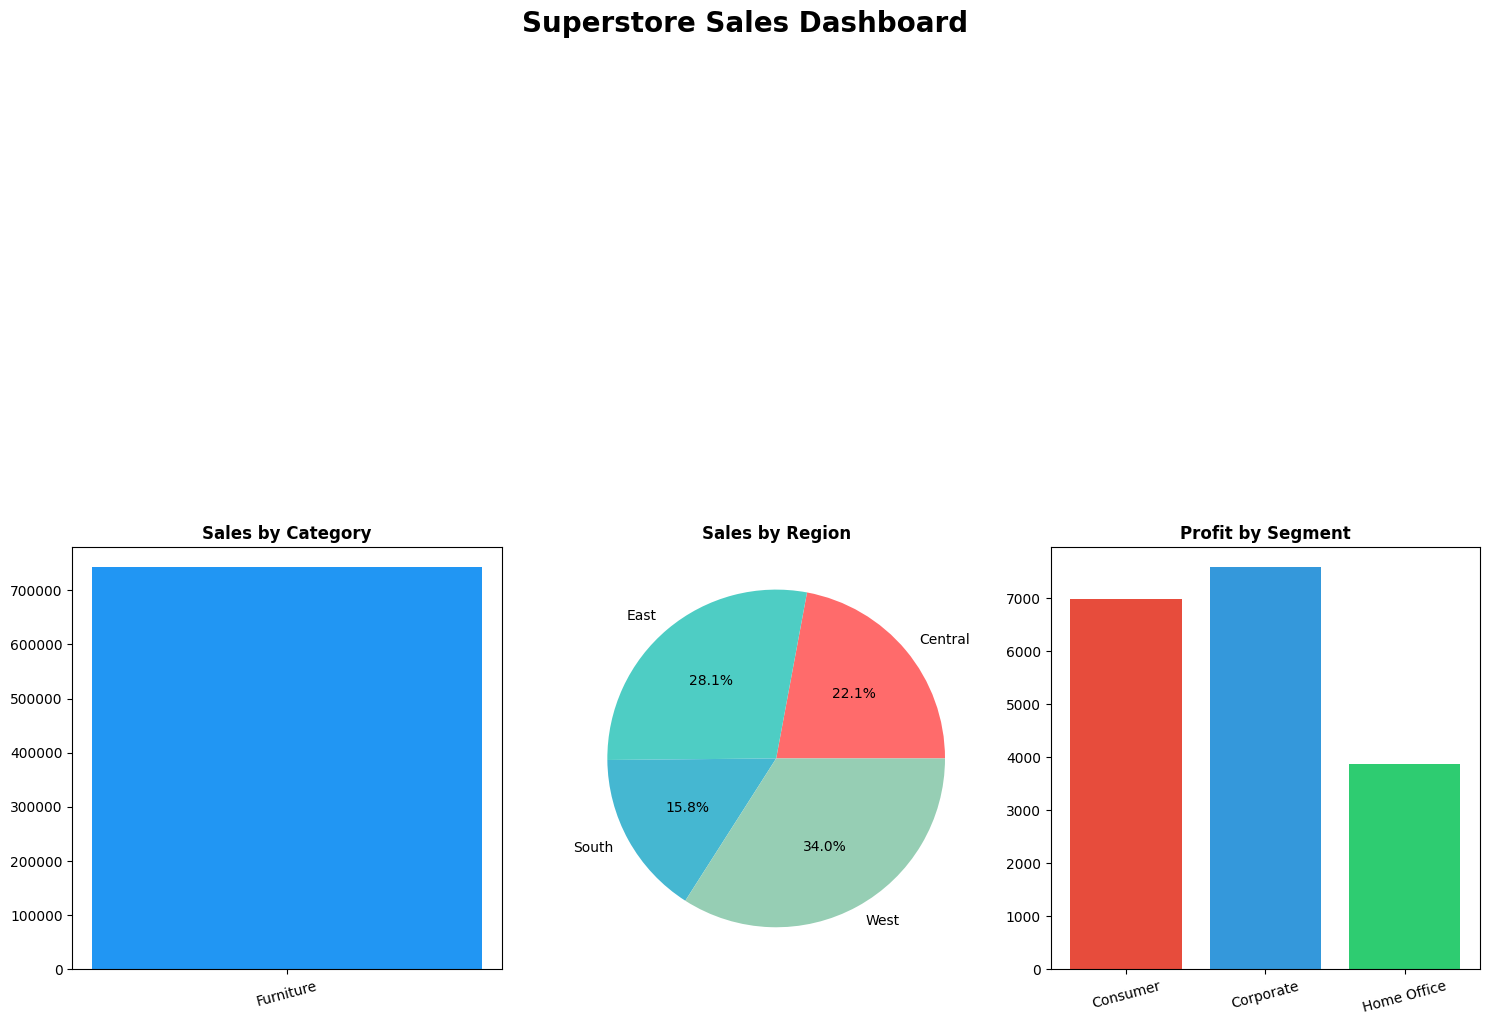

Dashboard Done!


In [7]:

# Chart 6: KPI Summary Dashboard
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Superstore Sales Dashboard', 
             fontsize=20, fontweight='bold', y=1.02)

# KPI 1 - Total Sales
total_sales = df['Sales'].sum()
axes[0,0].text(0.5, 0.5, f'Total Sales\n${total_sales:,.0f}', 
               ha='center', va='center', fontsize=16,
               fontweight='bold', color='white',
               transform=axes[0,0].transAxes)
axes[0,0].set_facecolor('#2196F3')
axes[0,0].axis('off')

# KPI 2 - Total Profit
total_profit = df['Profit'].sum()
axes[0,1].text(0.5, 0.5, f'Total Profit\n${total_profit:,.0f}', 
               ha='center', va='center', fontsize=16,
               fontweight='bold', color='white',
               transform=axes[0,1].transAxes)
axes[0,1].set_facecolor('#4CAF50')
axes[0,1].axis('off')

# KPI 3 - Total Orders
total_orders = df['Order ID'].nunique()
axes[0,2].text(0.5, 0.5, f'Total Orders\n{total_orders:,}', 
               ha='center', va='center', fontsize=16,
               fontweight='bold', color='white',
               transform=axes[0,2].transAxes)
axes[0,2].set_facecolor('#FF9800')
axes[0,2].axis('off')

# Chart - Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
axes[1,0].bar(category_sales.index, category_sales.values,
              color=['#2196F3','#FF9800','#4CAF50'])
axes[1,0].set_title('Sales by Category', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart - Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()
axes[1,1].pie(region_sales, labels=region_sales.index,
              autopct='%1.1f%%',
              colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
axes[1,1].set_title('Sales by Region', fontweight='bold')

# Chart - Profit by Segment
segment_profit = df.groupby('Segment')['Profit'].sum()
axes[1,2].bar(segment_profit.index, segment_profit.values,
              color=['#E74C3C','#3498DB','#2ECC71'])
axes[1,2].set_title('Profit by Segment', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard Done!")
